# Toolbox: Yeast PPI Network

This notebook works with the yeast PPI data from STRING. I remove the 4932 prefix, filter the links, and use NetworkX to analyse the graph. I also check essential proteins, connected components and shortest paths.

# 1. Setup and Imports

## 1.1 Install Requirements

In [44]:
%pip install -r requirements.txt

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.2 Import the required packages and set data path

In [46]:

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import scipy
import igraph as ig

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PPI_FILE = "/content/4932.protein.links.v12.0.txt.gz"
ESSENTIAL_FILE = "/content/Data - List of essential proteins of saccharomyces cerevisiae.csv"

# 2. Dta-loading and graph-building

## 2.1  Network Preparation Functions
- `load_ppi_links()` — Load and clean the PPI/STRING protein interaction data.
- `load_essential_proteins()` — Load the essential protein list and return their identifiers.
- `build_unweighted_graph()` — Build an undirected, unweighted PPI network.
- `remove_essential_proteins()` — Remove essential proteins from the network.


In [47]:
def load_ppi_links(path):
    """Load STRING links and clean the protein identifiers."""

    links = pd.read_csv(
        path,
        sep=r"\s+",
        compression="gzip"
    )

    required = {"protein1", "protein2", "combined_score"}
    missing = required.difference(links.columns)

    if missing:
        raise ValueError(
            f"Missing required STRING columns: {sorted(missing)}"
        )

    links = links.dropna(subset=list(required)).copy()

    links["protein1"] = links["protein1"].str.removeprefix("4932.")
    links["protein2"] = links["protein2"].str.removeprefix("4932.")

    links = links.loc[links["protein1"] != links["protein2"]]

    return links.reset_index(drop=True)


def load_essential_proteins(path):
    """Return the essential-protein table and its set of systematic ORF names."""
    columns = ["sgd_id", "systematic_name", "organism", "standard_name", "description"]
    table = pd.read_csv(path, header=None, names=columns)
    proteins = set(table["systematic_name"].dropna().astype(str).str.strip())
    proteins.discard("")
    return table, proteins


def build_unweighted_graph(links):
    """Build a simple, undirected and unweighted graph from a STRING link table."""
    return nx.from_pandas_edgelist(
        links, source="protein1", target="protein2", create_using=nx.Graph()
    )


def remove_essential_proteins(graph, essential_set):
    """Return a copy of graph with all listed essential proteins removed."""
    result = graph.copy()
    result.remove_nodes_from(essential_set)
    return result




## 2.2 Load the STRING PPI and essential file

In [48]:
ppi_data = load_ppi_links(PPI_FILE)
essential_table, essential_proteins = load_essential_proteins(ESSENTIAL_FILE)

display(essential_table.head())
display(ppi_data.head())


,sgd_id,systematic_name,organism,standard_name,description
0,S000000001,YAL001C,S. cerevisiae,TFC3,Transcription Factor class C
1,S000000003,YAL003W,S. cerevisiae,EFB1,Elongation Factor Beta
2,S000000010,YAL012W,S. cerevisiae,CYS3,CYStathionine gamma-lyase
3,S000000023,YAL025C,S. cerevisiae,MAK16,MAintenance of Killer
4,S000000030,YAL032C,S. cerevisiae,PRP45,Pre-mRNA Processing


,protein1,protein2,combined_score
0,Q0010,YMR207C,333
1,Q0010,YCR051W,205
2,Q0010,YPR002W,195
3,Q0010,YGR117C,166
4,Q0010,YML056C,152


## 2.3 Filter links using a confidence-score threshold

STRING scores show the confidence of each link. Use 750 as the cutoff.

In [49]:

def filter_by_confidence(links, threshold=750):
    """Keep only high-confidence PPI links."""
    return links.loc[links["combined_score"] > threshold].copy()

filtered_ppi_data=filter_by_confidence(ppi_data)
print("Number of links before filtering:", len((ppi_data)))
print("Number of links after filtering:", len(filtered_ppi_data))

filtered_ppi_data.head()

Number of links before filtering: 2824842
Number of links after filtering: 182546


,protein1,protein2,combined_score
85,Q0010,Q0297,945
125,Q0010,Q0032,956
157,Q0010,Q0143,954
324,Q0010,Q0182,916
548,Q0010,Q0142,843


## 2.4 Construct the three shared networks


In [50]:

karate_source = nx.karate_club_graph()
karate_graph = nx.Graph()
karate_graph.add_nodes_from(karate_source.nodes(data=True))
karate_graph.add_edges_from(karate_source.edges())
ppi_graph = build_unweighted_graph(filtered_ppi_data)
ppi_without_essential_graph = remove_essential_proteins(ppi_graph, essential_proteins)

G_karate = karate_graph
G_ppi = ppi_graph
G_ppi_no_essential = ppi_without_essential_graph

print(f"Retained STRING rows: {len(filtered_ppi_data):,}")
print(f"Essential proteins listed: {len(essential_table):,}")
print(f"Essential proteins found in filtered graph: {len(essential_proteins & set(G_ppi)):,}")


Retained STRING rows: 182,546
Essential proteins listed: 1,313
Essential proteins found in filtered graph: 1,244


## 2.5 Network Analysis Functions

These functions are used to analyse and query the PPI network:

- **get_shortest_path()** — Determine the shortest path length between two proteins.
- **get_largest_component()** — Find the largest connected component and count discarded nodes.
- **is_essential()** — Determine whether a protein is an essential protein.



In [51]:
def get_largest_component(graph):
    largest_nodes = max(nx.connected_components(graph), key=len)
    largest_graph = graph.subgraph(largest_nodes).copy()

    discarded_nodes = (
        graph.number_of_nodes()
        - largest_graph.number_of_nodes()
    )
    return largest_graph, discarded_nodes

def get_shortest_path(graph, protein1, protein2):
    if protein1 not in graph or protein2 not in graph:
        return None, None

    path = nx.shortest_path(
        graph,
        source=protein1,
        target=protein2
    )

    path_length = nx.shortest_path_length(
        graph,
        source=protein1,
        target=protein2
    )

    return path, path_length

def is_essential(protein):
    return protein in essential_proteins



# 3.Centrality Measures and PPI Network Analysis

## 3.1 centrality measures function

The function below calculates seven centrality measures for a given network:

- **Degree centrality**: measures the number of connections a node has relative to the size of the network.
- **Eigenvector centrality**: gives higher scores to nodes connected to other highly connected nodes.
- **Katz centrality**: considers both direct and indirect connections. A suitable `alpha` is required to ensure convergence.
- **PageRank**: ranks nodes according to the importance of their neighbours and the network structure.
- **Betweenness centrality**: measures how often a node lies on shortest paths between other nodes. It is calculated using `igraph` for faster exact computation.
- **Subgraph centrality**: measures the participation of a node in closed walks of different lengths. `subgraph_centrality_exp()` uses the matrix-exponential formulation.
- **Closeness centrality**: measures how close a node is to all other reachable nodes based on shortest-path distances. It is calculated using `igraph`.

NetworkX is used for most measures, while `igraph` is used for Betweenness and Closeness because these calculations are computationally expensive for the large yeast PPI network.

The function returns a dictionary where each key is a centrality measure and each value is a `{node: score}` mapping.


### Katz Centrality

Katz centrality measures node importance by considering both direct and indirect connections. It is defined by

$$
\mathbf{x}=\alpha A\mathbf{x}+\beta\mathbf{1},
$$

where $A$ is the adjacency matrix, $\alpha$ is the attenuation factor, $\beta$ is a baseline parameter, and $\mathbf{1}$ is the **all-ones vector**:

$$
\mathbf{1} =
\begin{bmatrix}
1\\
1\\
\vdots\\
1
\end{bmatrix}.
$$

Thus, $\beta\mathbf{1}$ gives every node the same baseline contribution $\beta$.

The calculation converges when

$$
\alpha < \frac{1}{\lambda_{\max}(A)},
$$

where $\lambda_{\max}(A)$ is the largest eigenvalue of the adjacency matrix.

When we first applied Katz centrality to the yeast PPI network, the calculation did not converge with the initial value of `alpha`. Therefore, we first need to determine the largest eigenvalue of the network.

For the full PPI network, this gives

$$
\lambda_{\max}=216.4662
$$

and therefore

$$
\alpha_{\max}=\frac{1}{216.4662}\approx0.0046197.
$$

NetworkX uses $\alpha=0.1$ by default for `nx.katz_centrality(G)`. Since

$$
0.1 > 0.0046197,
$$

the default value does not satisfy the convergence condition for this network.

We therefore use $\alpha=0.001$, which satisfies

$$
0.001 < 0.0046197.
$$

With a suitable value of $\alpha$ selected for Katz centrality, we can now calculate the seven centrality measures for the PPI network. The equations below define the centrality measures used in the analysis.


In [52]:
import scipy.sparse.linalg as spla
import scipy.sparse as sp
import numpy as np

A = nx.to_scipy_sparse_array(G_ppi, dtype=float)

lambda_max = spla.eigsh(
    A,
    k=1,
    which="LA",
    return_eigenvectors=False
)[0]

print("Largest eigenvalue:", lambda_max)
print("Maximum alpha for convergence:", 1 / lambda_max)

Largest eigenvalue: 216.46624805471123
Maximum alpha for convergence: 0.004619657840363421


In [53]:
def calculate_centralities(G):
    G_igraph = ig.Graph.from_networkx(G)

    return {
        "degree": nx.degree_centrality(G),

        "eigenvector": nx.eigenvector_centrality(G),

        "katz": nx.katz_centrality(
            G,
            alpha=0.001
        ),

        "pagerank": nx.pagerank(G),

        "betweenness": dict(zip(
            G.nodes(),
            G_igraph.betweenness(normalized=True)
        )),

        "subgraph": nx.subgraph_centrality_exp(G),

        "closeness": dict(zip(
            G.nodes(),
            G_igraph.closeness(normalized=True)
        )),
    }

### Centrality Calculation

The seven centrality measures are calculated for three networks:

- **Zachary Karate Club network**
- **Full yeast PPI network**
- **Yeast PPI network without essential proteins**

Each network is passed to `calculate_centralities()`, which returns the scores for all seven centrality measures.

In [54]:
karate_centralities = calculate_centralities(G_karate)

ppi_centralities = calculate_centralities(G_ppi)

ppi_no_essential_centralities = calculate_centralities(
    G_ppi_no_essential
)



## 3.2 Network validation and summary table

In [55]:
def network_summary(graph, name):
    """Return standard validation statistics for an undirected graph."""
    component_count = nx.number_connected_components(graph) if graph.number_of_nodes() else 0
    largest_component,_ = get_largest_component(graph)
    isolates = nx.number_of_isolates(graph)
    return {
        "network": name,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "connected_components": component_count,
        "largest_component_nodes": len(largest_component),
        "isolated_nodes": isolates,
        "is_directed": graph.is_directed(),
        "is_weighted": nx.is_weighted(graph),
        "self_loops": nx.number_of_selfloops(graph),
    }


network_summaries = pd.DataFrame([
    network_summary(G_karate, "Karate Club"),
    network_summary(G_ppi, "Yeast PPI (essential included)"),
    network_summary(G_ppi_no_essential, "Yeast PPI (essential removed)"),
])
network_summaries


,network,nodes,edges,connected_components,largest_component_nodes,isolated_nodes,is_directed,is_weighted,self_loops
0,Karate Club,34,78,1,34,0,False,False,0
1,Yeast PPI (essential included),5680,91273,61,5519,0,False,False,0
2,Yeast PPI (essential removed),4436,41067,125,4208,60,False,False,0


## 3.3 Common ranking and output functions

In [56]:
def rank_centrality(scores, centrality_name, network_name, top_n=5, essential_set=None):
    """Convert a {node: score} mapping into the group's standard ranked table."""
    if top_n < 1:
        raise ValueError("top_n must be at least 1")

    ranked = sorted(scores.items(), key=lambda item: (-item[1], str(item[0])))[:top_n]
    result = pd.DataFrame(ranked, columns=["node", "score"])
    result.insert(0, "rank", range(1, len(result) + 1))
    result.insert(1, "network", network_name)
    result.insert(2, "centrality", centrality_name)
    if essential_set is not None:
        result["is_essential"] = result["node"].isin(essential_set)
    return result


def largest_connected_component(graph):
    """Return a copy of the largest connected component (useful for path-based measures)."""
    if graph.number_of_nodes() == 0:
        return graph.copy()
    nodes = max(nx.connected_components(graph), key=len)
    return graph.subgraph(nodes).copy()


## 3.4 Smoke Test: Centrality Measures on All Three Networks

In [57]:
centrality_measures = [
    "degree",
    "eigenvector",
    "katz",
    "pagerank",
    "betweenness",
    "subgraph",
    "closeness",
]

centrality_test_results = {}

for measure in centrality_measures:
    centrality_test_results[measure] = pd.concat([
        rank_centrality(
            karate_centralities[measure],
            measure,
            "Karate Club",
            5,
        ),
        rank_centrality(
            ppi_centralities[measure],
            measure,
            "Yeast PPI (essential included)",
            5,
            essential_proteins,
        ),
        rank_centrality(
            ppi_no_essential_centralities[measure],
            measure,
            "Yeast PPI (essential removed)",
            5,
            essential_proteins,
        ),
    ], ignore_index=True)

for measure, results in centrality_test_results.items():
    print(f"\n=== {measure.capitalize()} Centrality ===")
    display(results)


=== Degree Centrality ===


,rank,network,centrality,node,score,is_essential
0,1,Karate Club,degree,33,0.515152,NaN
1,2,Karate Club,degree,0,0.484848,NaN
2,3,Karate Club,degree,32,0.363636,NaN
3,4,Karate Club,degree,2,0.303030,NaN
4,5,Karate Club,degree,1,0.272727,NaN
5,1,Yeast PPI (essential included),degree,YNL178W,0.072372,True
6,2,Yeast PPI (essential included),degree,YDR064W,0.070435,True
7,3,Yeast PPI (essential included),degree,YJR123W,0.068674,True
8,4,Yeast PPI (essential included),degree,YOR063W,0.066209,True
9,5,Yeast PPI (essential included),degree,YGL123W,0.065681,True



=== Eigenvector Centrality ===


,rank,network,centrality,node,score,is_essential
0,1,Karate Club,eigenvector,33,0.373371,NaN
1,2,Karate Club,eigenvector,0,0.355483,NaN
2,3,Karate Club,eigenvector,2,0.317189,NaN
3,4,Karate Club,eigenvector,32,0.308651,NaN
4,5,Karate Club,eigenvector,1,0.265954,NaN
5,1,Yeast PPI (essential included),eigenvector,YDR064W,0.080649,True
6,2,Yeast PPI (essential included),eigenvector,YJR123W,0.079416,True
7,3,Yeast PPI (essential included),eigenvector,YCR031C,0.078390,False
8,4,Yeast PPI (essential included),eigenvector,YNL178W,0.078003,True
9,5,Yeast PPI (essential included),eigenvector,YBR048W,0.076843,False



=== Katz Centrality ===


...

,rank,network,centrality,node,score,is_essential
0,1,Karate Club,betweenness,0,0.411892,NaN
1,2,Karate Club,betweenness,33,0.286188,NaN
2,3,Karate Club,betweenness,32,0.136703,NaN
3,4,Karate Club,betweenness,2,0.135206,NaN
4,5,Karate Club,betweenness,31,0.130142,NaN
5,1,Yeast PPI (essential included),betweenness,YFL039C,0.048581,True
6,2,Yeast PPI (essential included),betweenness,YFL038C,0.031025,True
7,3,Yeast PPI (essential included),betweenness,YBR160W,0.023616,True
8,4,Yeast PPI (essential included),betweenness,YLR167W,0.021877,True
9,5,Yeast PPI (essential included),betweenness,YLL039C,0.018923,False



=== Subgraph Centrality ===


,rank,network,centrality,node,score,is_essential
0,1,Karate Club,subgraph,33,1.367223e+02,NaN
1,2,Karate Club,subgraph,0,1.280950e+02,NaN
2,3,Karate Club,subgraph,32,9.569473e+01,NaN
3,4,Karate Club,subgraph,2,8.870459e+01,NaN
4,5,Karate Club,subgraph,1,7.143100e+01,NaN
5,1,Yeast PPI (essential included),subgraph,YDR064W,6.657036e+91,True
6,2,Yeast PPI (essential included),subgraph,YJR123W,6.455095e+91,True
7,3,Yeast PPI (essential included),subgraph,YCR031C,6.289201e+91,False
8,4,Yeast PPI (essential included),subgraph,YNL178W,6.227439e+91,True
9,5,Yeast PPI (essential included),subgraph,YBR048W,6.043420e+91,False



=== Closeness Centrality ===


,rank,network,centrality,node,score,is_essential
0,1,Karate Club,closeness,0,0.568966,NaN
1,2,Karate Club,closeness,2,0.559322,NaN
2,3,Karate Club,closeness,33,0.550000,NaN
3,4,Karate Club,closeness,31,0.540984,NaN
4,5,Karate Club,closeness,13,0.515625,NaN
5,1,Yeast PPI (essential included),closeness,YAL056C-A,1.000000,False
6,2,Yeast PPI (essential included),closeness,YAL059C-A,1.000000,False
7,3,Yeast PPI (essential included),closeness,YAL068W-A,1.000000,False
8,4,Yeast PPI (essential included),closeness,YAL069W,1.000000,False
9,5,Yeast PPI (essential included),closeness,YAR053W,1.000000,False


#4 Comparison of indicators and final selection

##4.1 Load data and build dataframe

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['degree', 'eigenvector', 'katz', 'pagerank', 'betweenness', 'subgraph', 'closeness']
labels = ['Degree', 'Eigenvector', 'Katz', 'PageRank', 'Betweenness', 'Subgraph', 'Closeness']

df = pd.DataFrame({labels[i]: ppi_centralities[metrics[i]] for i in range(len(metrics))})
print(f"Loaded {df.shape[0]} nodes, {df.shape[1]} centrality measures")
df.head()

Loaded 5680 nodes, 7 centrality measures


,Degree,Eigenvector,Katz,PageRank,Betweenness,Subgraph,Closeness
Q0010,0.001233,2.750900e-07,0.012851,0.000145,0.0,7.757220e+80,0.190355
Q0297,0.001233,2.750900e-07,0.012851,0.000145,0.0,7.757220e+80,0.190355
Q0032,0.001233,2.750900e-07,0.012851,0.000145,0.0,7.757220e+80,0.190355
Q0143,0.001233,2.750900e-07,0.012851,0.000145,0.0,7.757220e+80,0.190355
Q0182,0.001233,2.750900e-07,0.012851,0.000145,0.0,7.757220e+80,0.190355


##4.2 Correlation matrix


In [60]:
corr = df.corr()
print("Correlation matrix:")
print(corr.round(3))

Correlation matrix:
             Degree  Eigenvector   Katz  PageRank  Betweenness  Subgraph  \
Degree        1.000        0.936  0.998     0.760        0.303     0.891   
Eigenvector   0.936        1.000  0.956     0.558        0.150     0.961   
Katz          0.998        0.956  1.000     0.729        0.277     0.910   
PageRank      0.760        0.558  0.729     1.000        0.617     0.544   
Betweenness   0.303        0.150  0.277     0.617        1.000     0.132   
Subgraph      0.891        0.961  0.910     0.544        0.132     0.000   
Closeness     0.130        0.116  0.129     0.209        0.046     0.104   

             Closeness  
Degree           0.130  
Eigenvector      0.116  
Katz             0.129  
PageRank         0.209  
Betweenness      0.046  
Subgraph         0.104  
Closeness        1.000  


##4.3 Heatmap

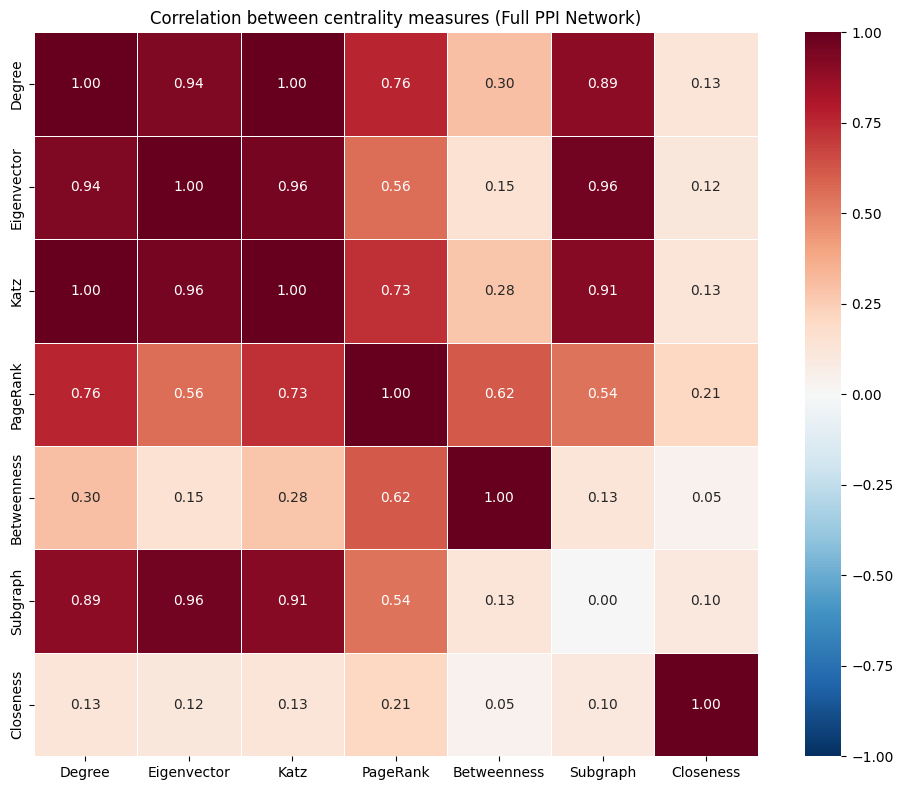

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation between centrality measures (Full PPI Network)')
plt.tight_layout()
plt.show()

##4.4 Scatter plot matrix

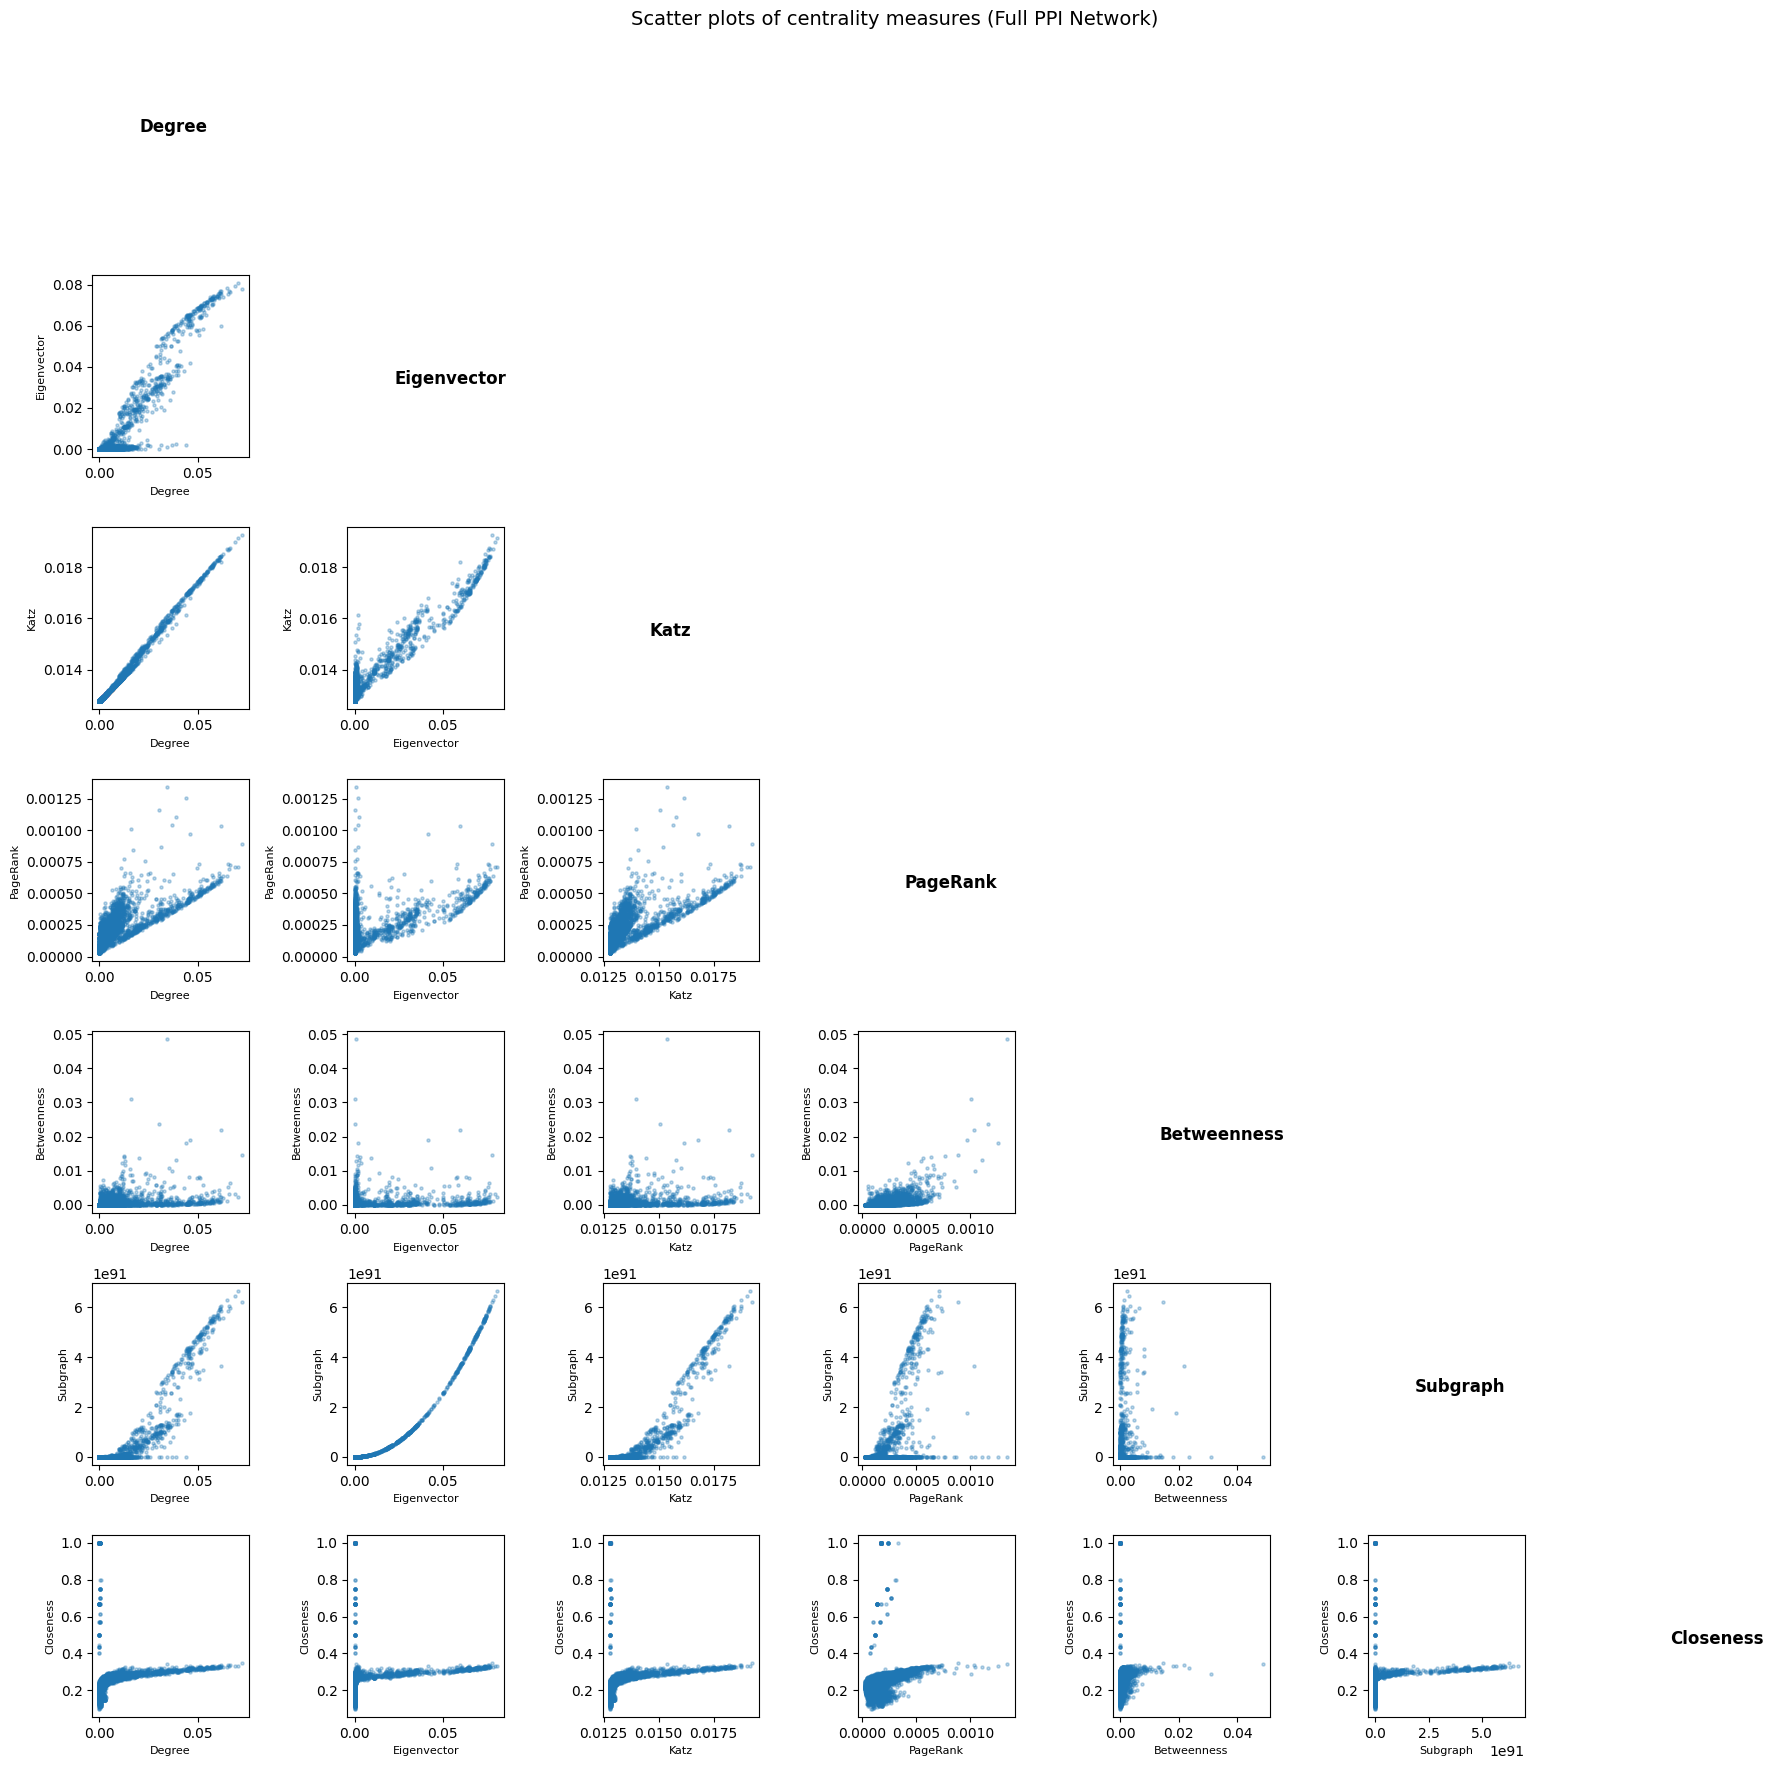

In [62]:
fig, axes = plt.subplots(7, 7, figsize=(18, 18))
for i in range(7):
    for j in range(7):
        if i == j:
            axes[i, j].text(0.3, 0.4, labels[i], fontsize=12, fontweight='bold')
            axes[i, j].axis('off')
        elif i > j:
            axes[i, j].scatter(df[labels[j]], df[labels[i]], s=5, alpha=0.3)
            axes[i, j].set_xlabel(labels[j], fontsize=8)
            axes[i, j].set_ylabel(labels[i], fontsize=8)
        else:
            axes[i, j].axis('off')
plt.suptitle('Scatter plots of centrality measures (Full PPI Network)', fontsize=14)
plt.tight_layout()
plt.show()

## 4.5 Find highly correlated pairs

In [63]:
threshold = 0.85
high_corr_pairs = []
for i in range(7):
    for j in range(i+1, 7):
        r = corr.iloc[i, j]
        if abs(r) > threshold:
            high_corr_pairs.append((labels[i], labels[j], round(r, 3)))

print(f"\nPairs with |r| > {threshold}:")
for pair in high_corr_pairs:
    print(f"  {pair[0]} -- {pair[1]}: r = {pair[2]}")


Pairs with |r| > 0.85:
  Degree -- Eigenvector: r = 0.936
  Degree -- Katz: r = 0.998
  Degree -- Subgraph: r = 0.891
  Eigenvector -- Katz: r = 0.956
  Eigenvector -- Subgraph: r = 0.961
  Katz -- Subgraph: r = 0.91


## 4.6 Data-driven summary

In [66]:
avg_corr = corr.mean(axis=1) - 1
most_unique = avg_corr.idxmin()
least_unique = avg_corr.idxmax()

recommended = set(labels)

removed = set()
for m1, m2, r in high_corr_pairs:
    if m1 in recommended and m2 in recommended:
        if avg_corr[m1] < avg_corr[m2]:
            removed.add(m2)
        else:
            removed.add(m1)

for m in removed:
    if m in recommended:
        recommended.remove(m)

if most_unique not in recommended:
    recommended.add(most_unique)

print("\n" + "="*60)
print("Final Recommendation (Data-Driven)")
print("="*60)
print(f"\nMost unique measure: {most_unique}")
print(f"Most redundant measure: {least_unique}")
print(f"\nRecommended ({len(recommended)} measures):")
for m in sorted(recommended):
    print(f"  - {m}")
print(f"\nExcluded ({len(excluded)} measures):")
for m in sorted(excluded):
    print(f"  - {m}")
print("\n" + "="*60)


Final Recommendation (Data-Driven)

Most unique measure: Closeness
Most redundant measure: Degree

Recommended (4 measures):
  - Betweenness
  - Closeness
  - PageRank
  - Subgraph

Excluded (3 measures):
  - Degree
  - Eigenvector
  - Katz



## 4.7 Conclusion

Although Closeness is the most distinctive in terms of statistics, due to the disconnected nature of the yeast PPI network (with 61 connected components), the calculation result of Closeness is unreliable. Therefore, it is excluded in practical applications. Ultimately, our recommendation is Betweenness + PageRank + Subgraph.